In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo0 version:", amigo.__version__)
print("dorito version:", dorito.__version__)

ERROR:2026-08-26 05:47:43,197:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


cpu
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo0 version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    if gethostname().startswith("max-"):
        jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    else:
        jax.config.update("jax_compilation_cache_dir", "/fred/oz440/max/jax_cache")

    jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 50
# intermediate_prints = [1000, 5000, 10000, 15000]
# intermediate_prints = [200, 5000]
intermediate_prints = [100, 1000]
# intermediate_prints = list(range(1000, 19000, 2000))
n_files_per_filt = 3
n_vals_per_filt = 1
one_filt_flag = False
binary_flag = False
val_flag = False
flat_flag = True
flat_only = False
static_optics = False
plot_flag = check_script()
plot_flag = True
save_flag = check_script()
recalculate_flag = False
best_state = load_dict(amigo_files_path + "/scratch_final_state.npy")
# best_state = load_dict(amigo_files_path + "/final_statev21.npy")


if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpuv3-0-12
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [3]:
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)



def add_badpix(file):
    # file["BADPIX"].data = badpix
    file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files
from dorito.misc import truncate_files


dark_files = []
print()
print("DARKS")
program_path = os.path.join(data_dir, "DARKS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_DARK")
dark_files += files

dark_files = [add_badpix(file) for file in dark_files]
truncate_files(dark_files, 500)  # TRUNCATING RAMP
summarise_files(dark_files)


DARKS
  program   target filter dither      g/i date             PI   CAL
0    1499  UNKNOWN  F430M    1/1  800/270  NaN  Martel, Andre  FLAT
1    6652  UNKNOWN  F430M    1/1  50/3752  NaN  Martel, Andre  FLAT


# Exposures

In [5]:
from amigo.model_fits import ModelFit
import dLux as dl
from dLux import utils as dlu

class DarkFit(ModelFit):

    def __init__(self, file, fit_one_on_fs=False, **kwargs):
        file[0].header["IS_PSF"] = False

        super().__init__(file, **kwargs)
        self.star = "NIS_DARK"
        self.observation = "DARK"
        self.program = "DARK"
        self.fit_one_on_fs = fit_one_on_fs
        self.fit_reflectivity = False
        self.fit_bias = False
        self.validator = False

    def print_summary(self):
        print(
            f"File {self.key}\n"
            f"Star {self.star}\n"
            f"nints {self.nints}\n"
            f"ngroups {len(self.slopes)+1}\n"
        )

    def initialise_params(self, optics, vis_model=None, one_on_fs_order=1):
        params = {}
        return params

    @property
    def key(self):
        return "_".join(["dark", str(self.ngroups)])

    # def get_key(self, param):
    #     if param in ["dark_A"]:
    #         return self.key
    #     return super().get_key(param)

    def model_illuminance(self, model):
        """
        There is no illuminance! Haha!
        """
        # Get the pixel scale (arcseconds)
        pixel_scale = model.optics.psf_pixel_scale / model.optics.oversample
        npix = model.optics.psf_npixels * model.optics.oversample

        # illuminance is just zeros
        illuminance = np.zeros((npix, npix))

        # Make the object and return
        return dl.PSF(illuminance, dlu.arcsec2rad(pixel_scale))

    def model_ramp(self, illuminance, model):
        # Get the charge (bias)
        illum_small = dlu.downsample(illuminance.data, 3, mean=False)

        # NOTE: This bias estimate is inadequate becuase it doesnt correctly account
        # for the non-linear component of the gain. This ultimately should be properly
        # calibrated, WITH the gain term using the ramp rather than slope data.
        #
        # TODO: USe quadratic formula to get correct non-linear inversion
        true_bias = model.read.gain * self.ramp[0]
        bias = true_bias - (illum_small / self.ngroups)

        # bias = self.ramp[0] - (illum_small / self.ngroups)
        # bias = model.read.gain * bias

        # Paste badpixels with median
        bias = np.where(self.badpix, np.median(bias), bias)

        # Evolve the illuminance
        # Don't need to bother with modelling charge bleeding here
        no_bleed = model.ramp_model.set("bleed", False)
        ramp = no_bleed.evolve_illuminance(illuminance.data, bias, self.ngroups)
        return Ramp(ramp, illuminance.pixel_scale)

    def simulate(self, model, return_slopes=False):
        illuminance = self.model_illuminance(model)
        ramp = self.model_ramp(illuminance, model)
        ramp = self.model_read(ramp, model)

        if return_slopes:
            return ramp.set("data", np.diff(ramp.data, axis=0))
        return ramp

In [6]:
# from retrain_fns import DarkFit

# Construct the exposures
dark_exposures = [DarkFit(file, use_cov=False) for file in dark_files]
exposures = dark_exposures[1:2]

# _ = [f.close() for f in dark_files]

# Building model

In [7]:
from amigo.read_models import ReadLayer, LayeredDetector, IPC, PixelNonLinearity, Amplifier
from amigo.ramp_models import Ramp
from importlib import resources
from jax import Array


class DarkCurrent(ReadLayer):
    dark_current: Array
    per_pixel: bool

    def __init__(self, dark_current, per_pixel=False):
        self.dark_current = np.array(dark_current, float)
        self.per_pixel = per_pixel

        if self.per_pixel:
            assert self.dark_current.shape == (80, 80)
        elif not self.per_pixel:
            assert self.dark_current.shape == ()
        
    def apply(self, ramp):
        group_range = np.arange(len(ramp.data)) + 1
        if self.per_pixel:
            dark_current = self.dark_current * group_range[:, None, None]
            return ramp.add("data", dark_current)
        else:
            dark_current = self.dark_current * group_range
            return ramp.add("data", dark_current[..., None, None])

class ReadModel(LayeredDetector):

    def __init__(
        self,
        dark_current=0.25,
        ipc=True,
        one_on_fs=None,
        gain=1.61,
        per_pixel=False,
    ):

        if ipc:
            # NOTE change this back when actually putting inside amigo package
            # file_path = resources.files(__package__) / "data" / "SUB80_ipc.npy"
            file_path = resources.files("amigo") / "data" / "SUB80_ipc.npy"
            ipc = IPC(np.load(file_path))
        else:
            ipc = None

        super().__init__(
            [
                ("read", DarkCurrent(dark_current, per_pixel)),
                ("pixel_non_linearity", PixelNonLinearity(gain=gain)),
                ("IPC", ipc),
                ("amplifier", Amplifier(one_on_fs)),
            ]
        )

In [8]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
# from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=True),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    # read=ReadModel(dark_current=0.45*np.eye(80), per_pixel=True),
    read=ReadModel(dark_current=0.45*np.ones((80, 80)), per_pixel=True),
    # read=ReadModel(dark_current=np.eye(80)),
    # read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

Populate from state.

In [9]:
state = load_dict(amigo_files_path + "/calibration.npy")

if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
    del state["jitter"]
    
for key, value in state.items():
    print(key)
    if key == "transmission" and not static_optics:
        continue
    if key in ["primary_beam", "distortion"] and static_optics:
        continue
    if key in [
        'aberrations',
        # 'primary_beam',
        # 'distortion',
        # 'transmission',
        'badpix',
        'dark_current',
    ]:
        continue
    model = model.set(key, value)

            

# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

FF
SRF
non_linearity
dark_current
defocus
nn_weights
aberrations
transmission
badpix
sigma


DARK F430M NIS_DARK 50 3752


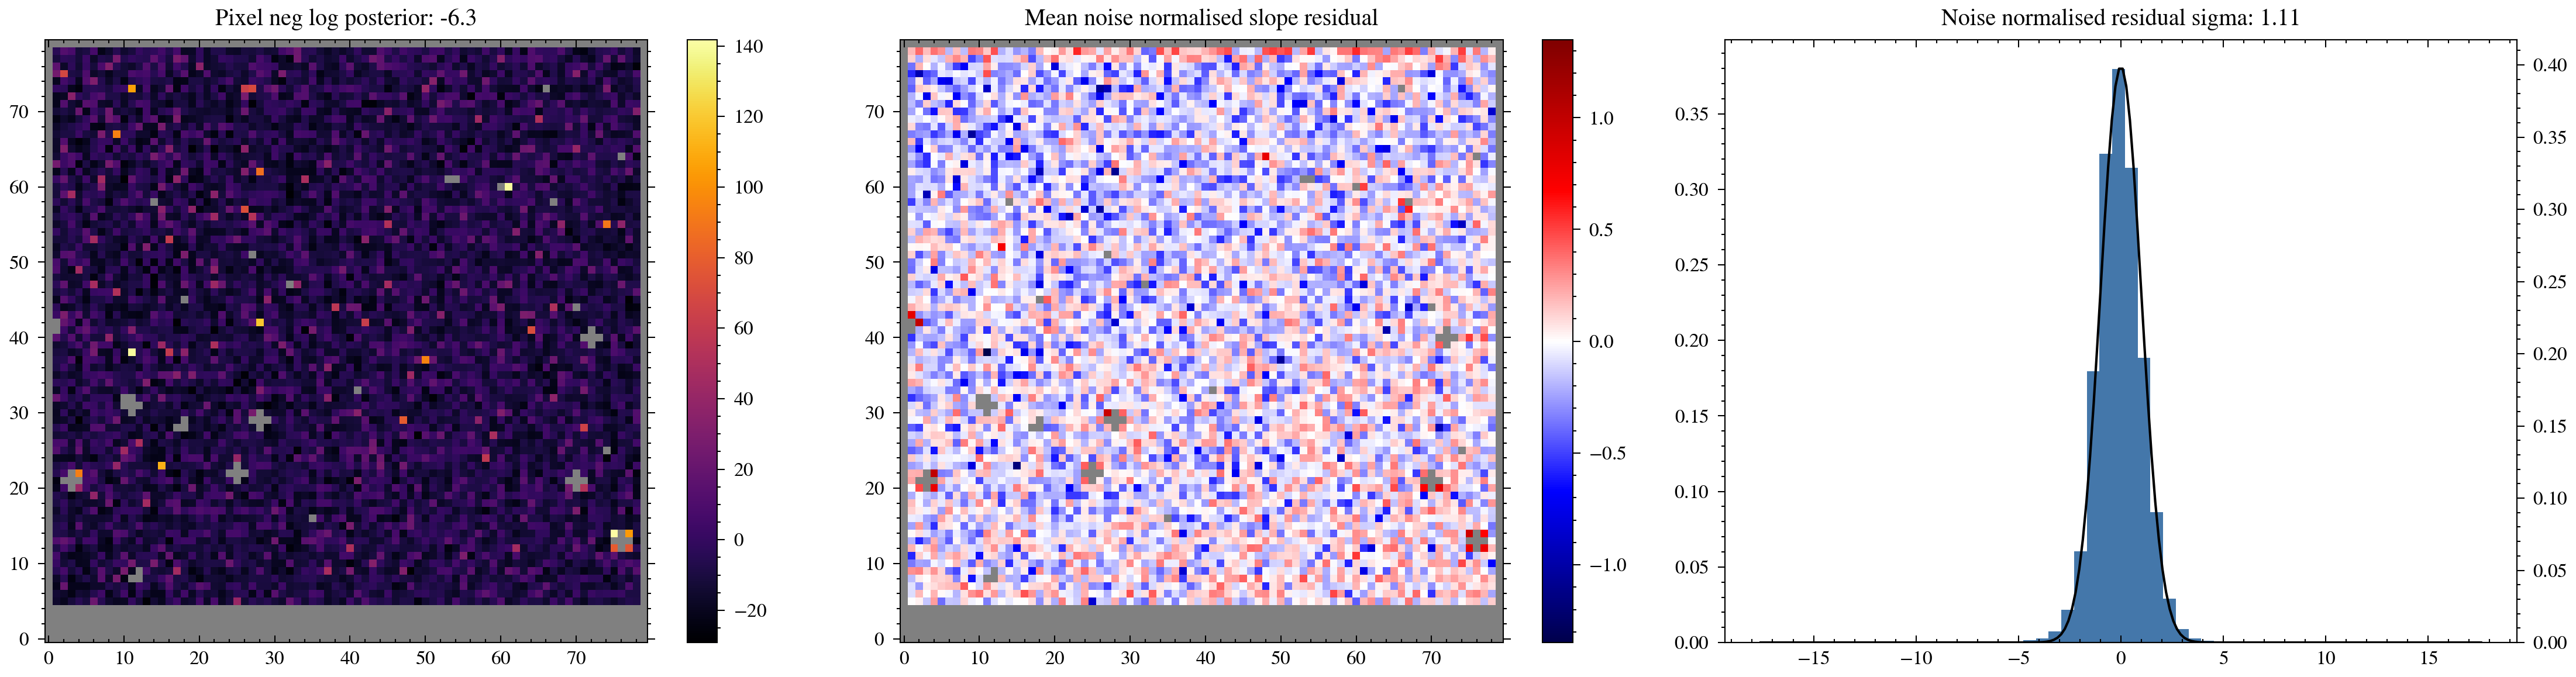

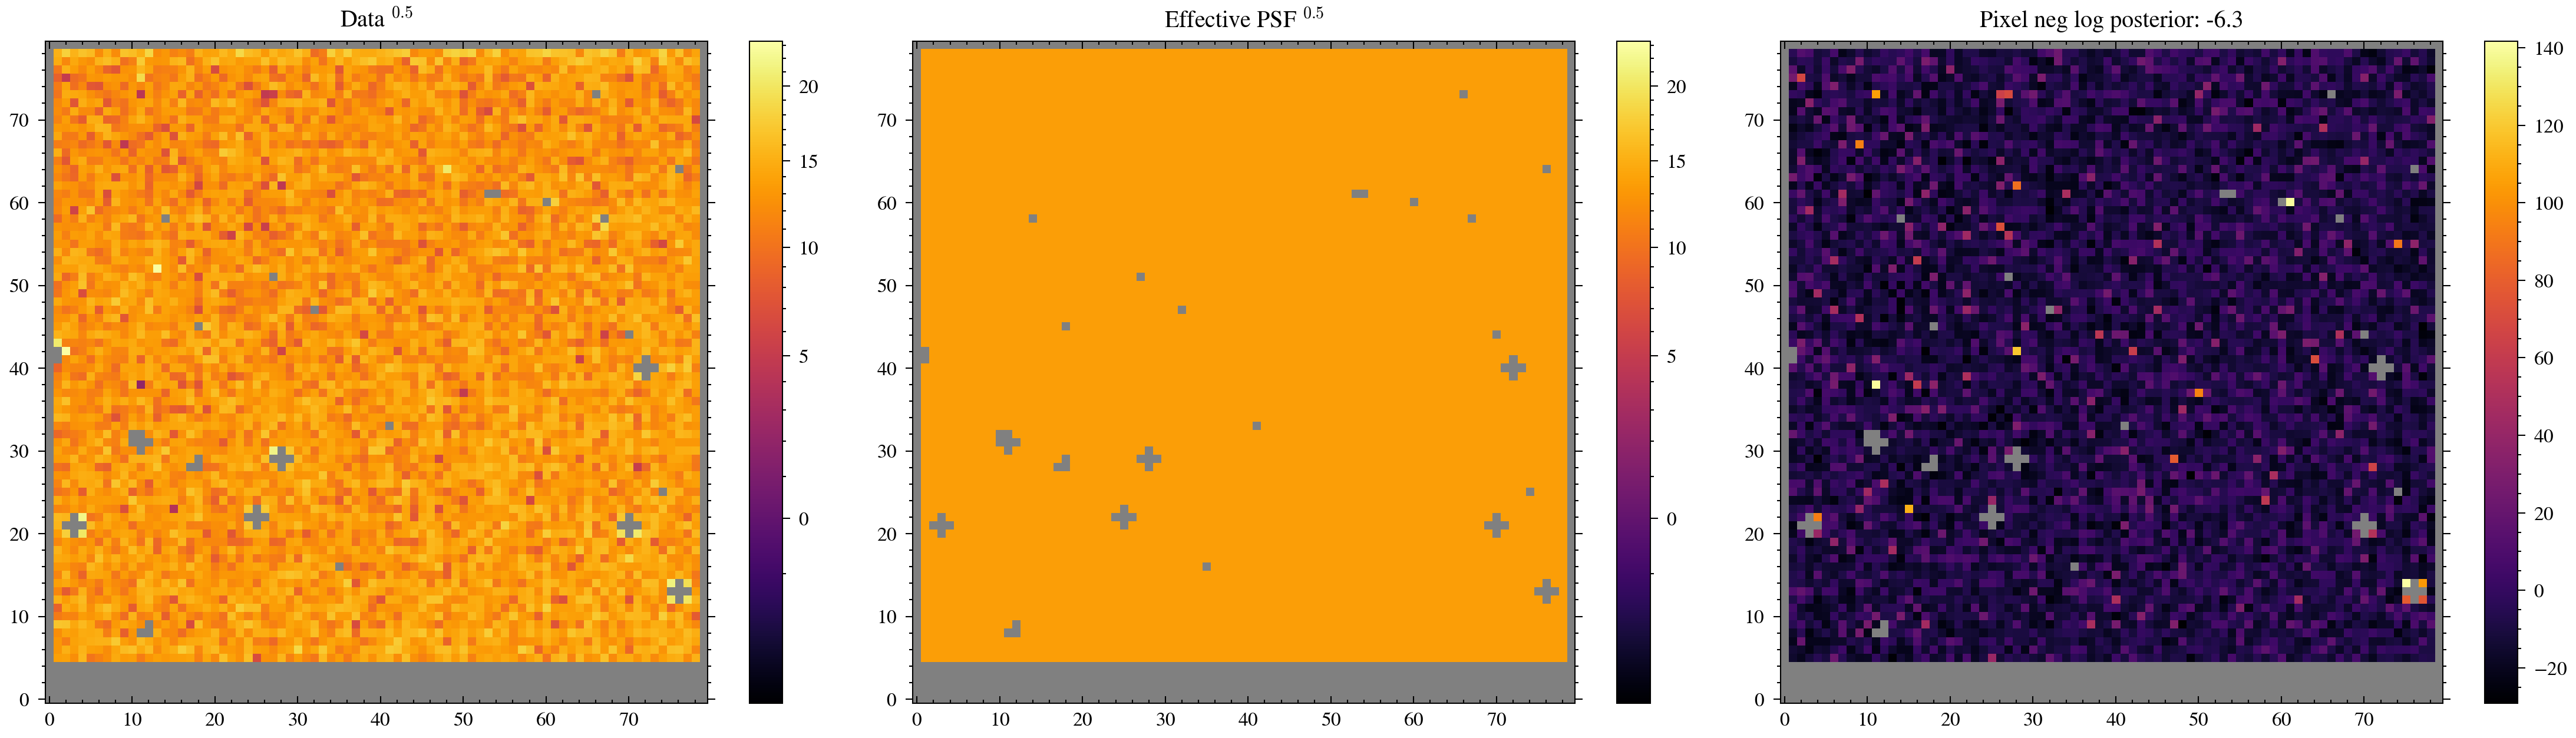

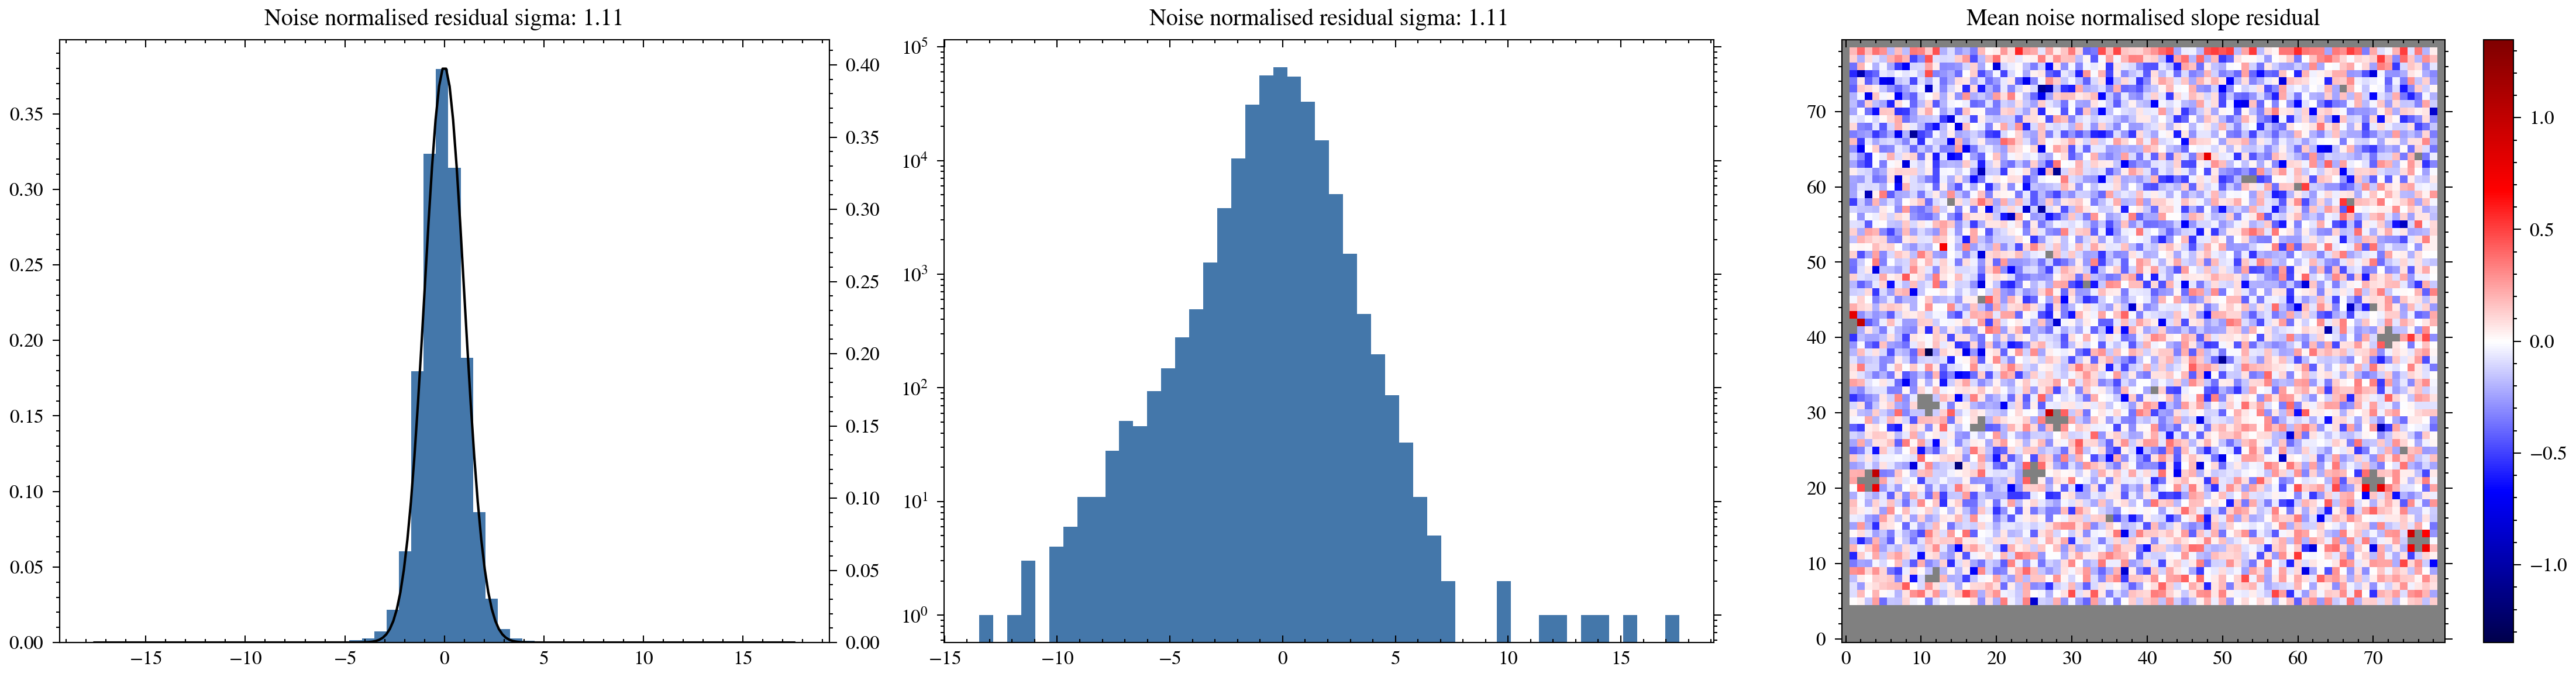

In [10]:
from amigo.plotting import summarise_fit

if plot_flag:
    for exp in exposures:
        print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
        summarise_fit(model, exp, histograms=True, residuals=True)
        # summarise_fit(model, exp, save_path=save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [32]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    grads_fn,
    aux_fn,
)

def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    # dark current
    if hasattr(model_params, "dark_current"):
        DC = model_params.dark_current
        med = np.median(DC)
        DC = np.where(dark_exposures[-1].badpix, med, DC)
        # DC = np.where(badpix, med, DC)
        model_params = model_params.set("dark_current", DC)

    # dc = model_params.dark_current
    # print(dc)

    return model_params, args


Instantiating trainer class and updating fishers.

In [33]:
# from amigo.calibration import ValBatchedTrainer  #, looper_fn, Trainer, aux_fn
from amigo.calibration import Trainer
from dorito.stats import apply_regularisers    

recalculate_flag = False

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer = Trainer(
# trainer = ValBatchedTrainer(
    loss_fn,
    # grad_fn=grads_fn,
    norm_fn=norm_fn,
    cache=cache_dir,
)

trainer = trainer.update_fishers(
    linear_model,
    exposures,
    parameters=["dark_current"],
    recalculate=recalculate_flag,
)


  0%|          | 0/1 [00:00<?, ?it/s]

Training.

In [34]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "dark_current": sgd(3e-2, 0),
    # "dark_A": sgd(1e-1, 0),
    # "non_linearity": sgd(1e-400, 100),
    # "non_linearity": sgd(1e-4, 10),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

# Train the model
# with jax.disable_jit():
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches={"0": exposures},
)

  0%|          | 0/50 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 60.59
Estimated run time: 0:00:22
Full Time: 0:00:21
Final Loss: 57.00


Plotting the results of that fit!

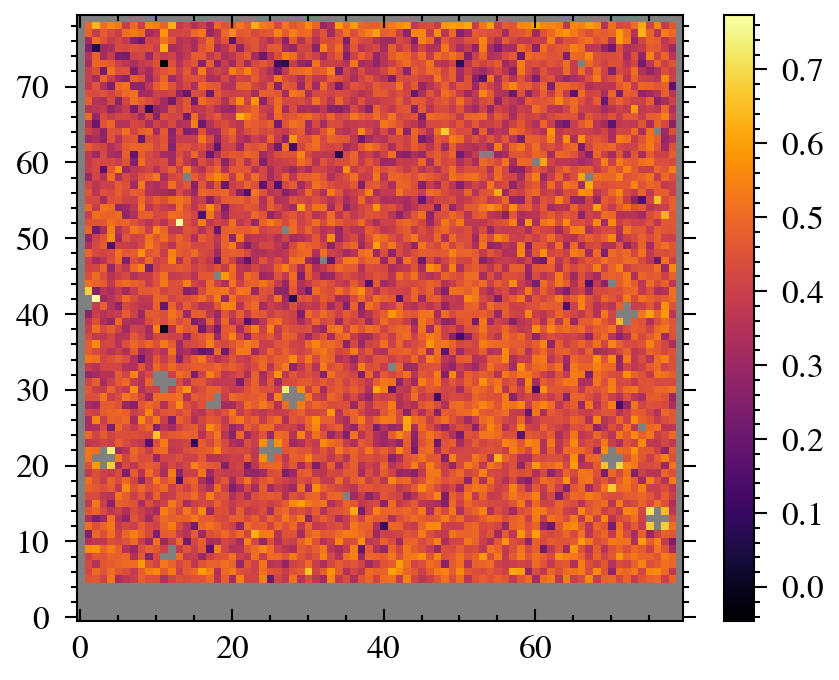

In [35]:
plt.imshow(np.where(exp.badpix, np.nan, result.model.dark_current), inferno)
plt.colorbar()
plt.show()

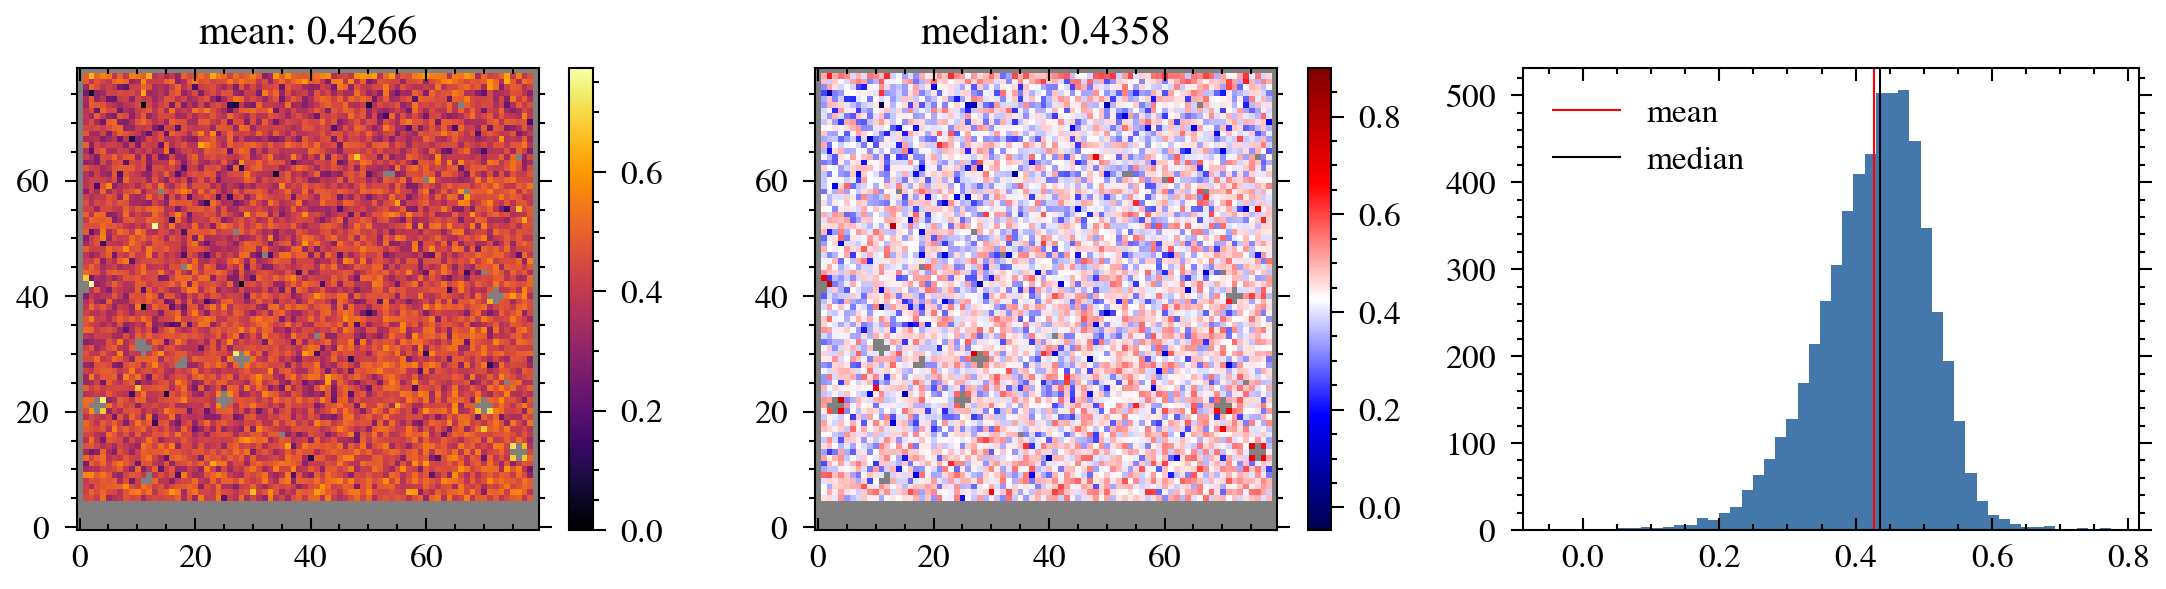

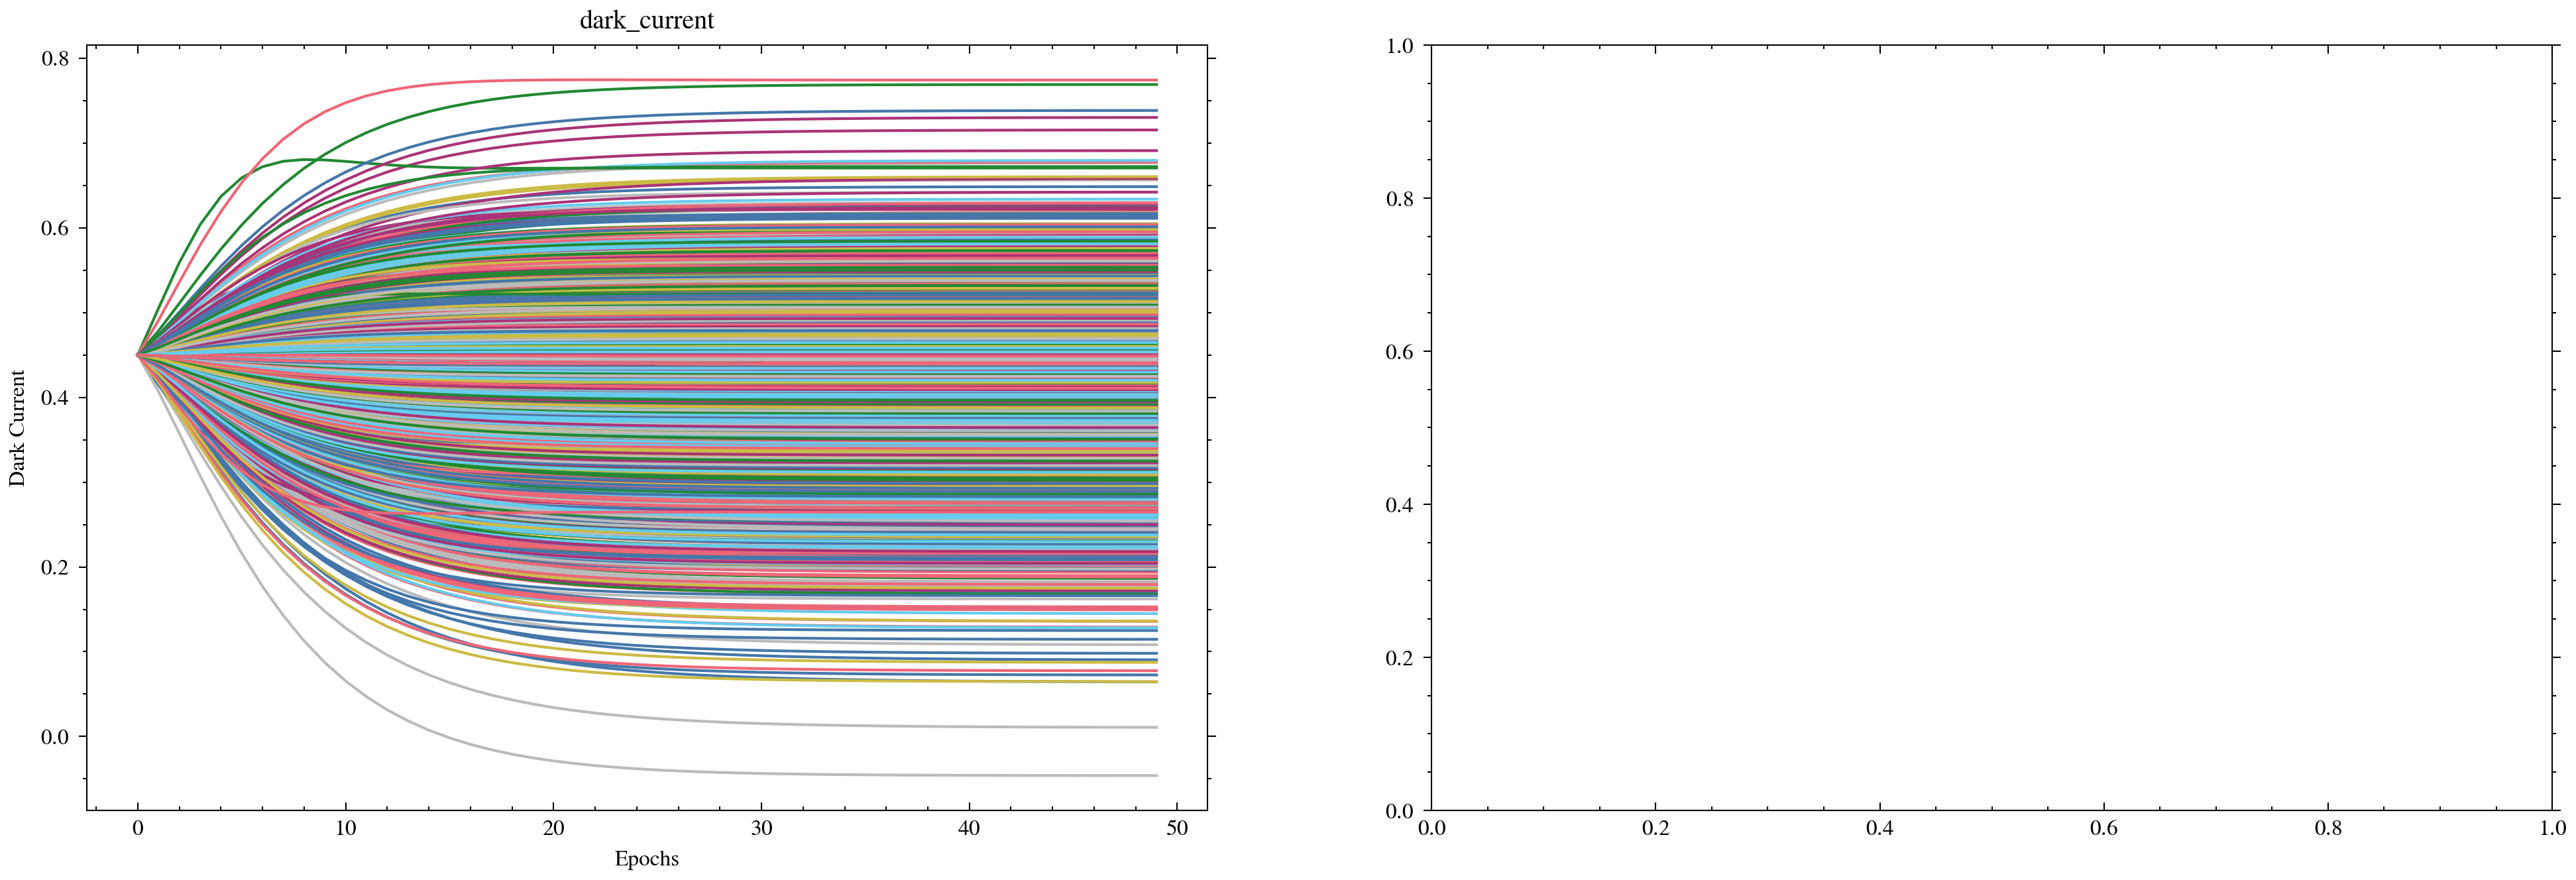

File dark_50
Star NIS_DARK
nints 3752
ngroups 50



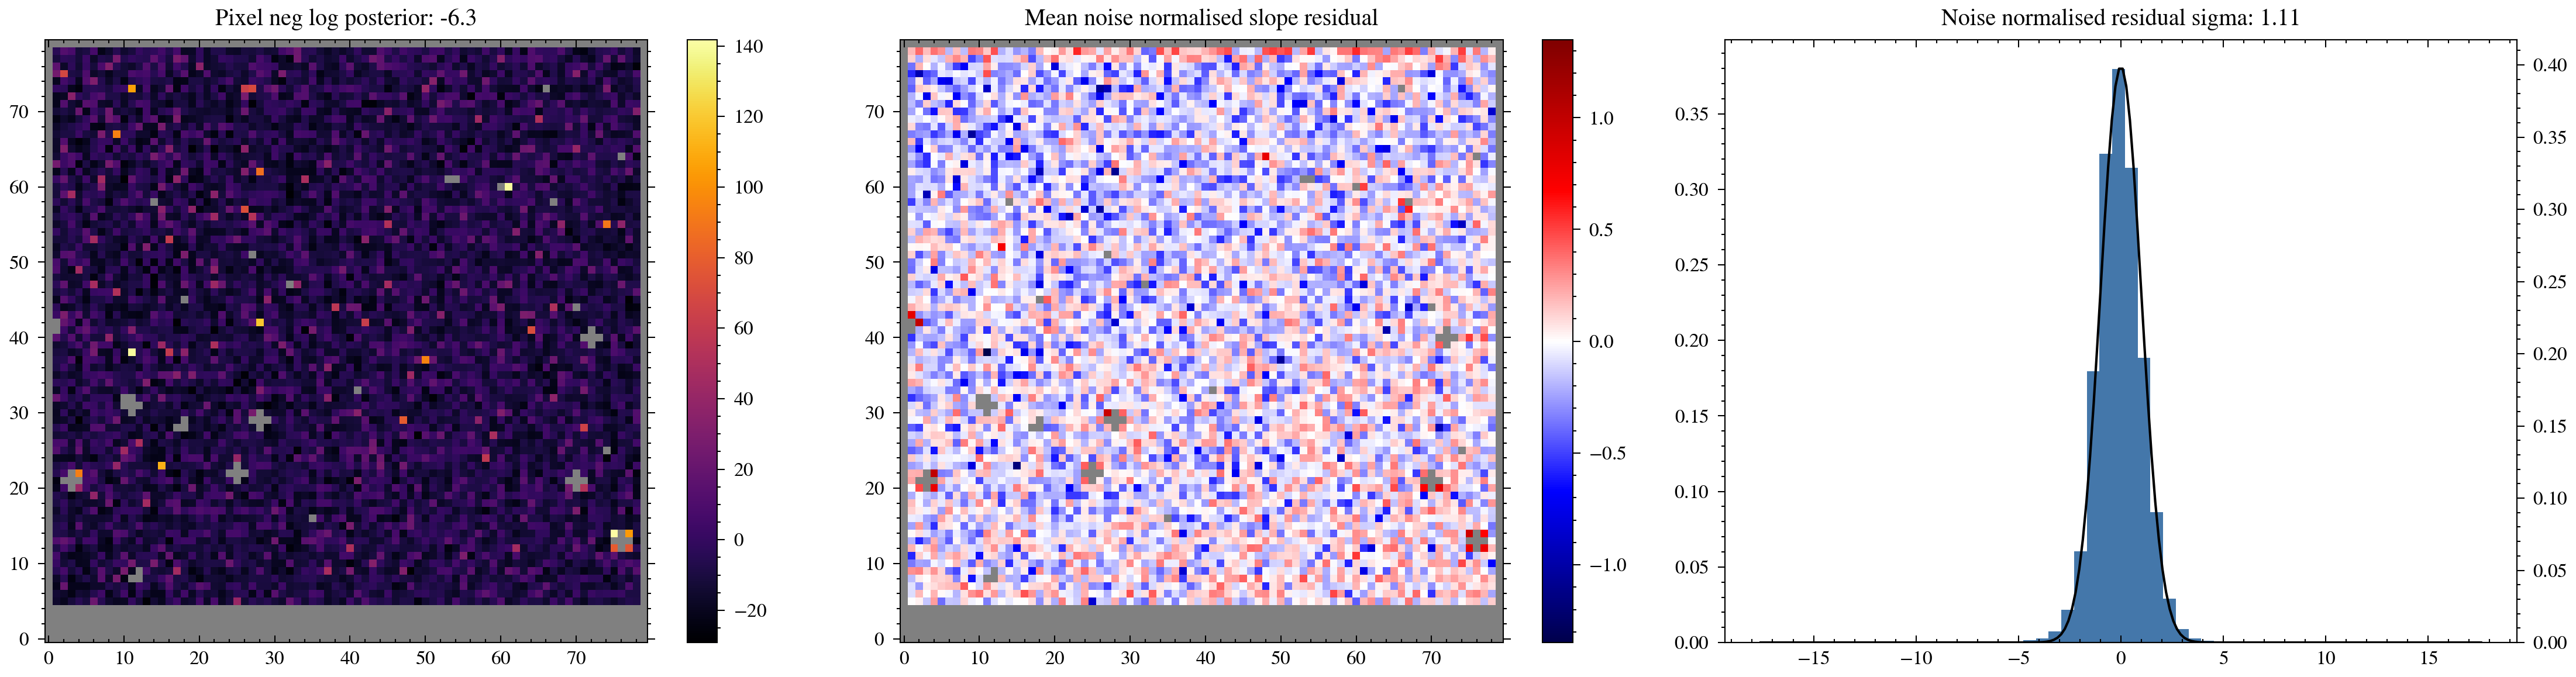

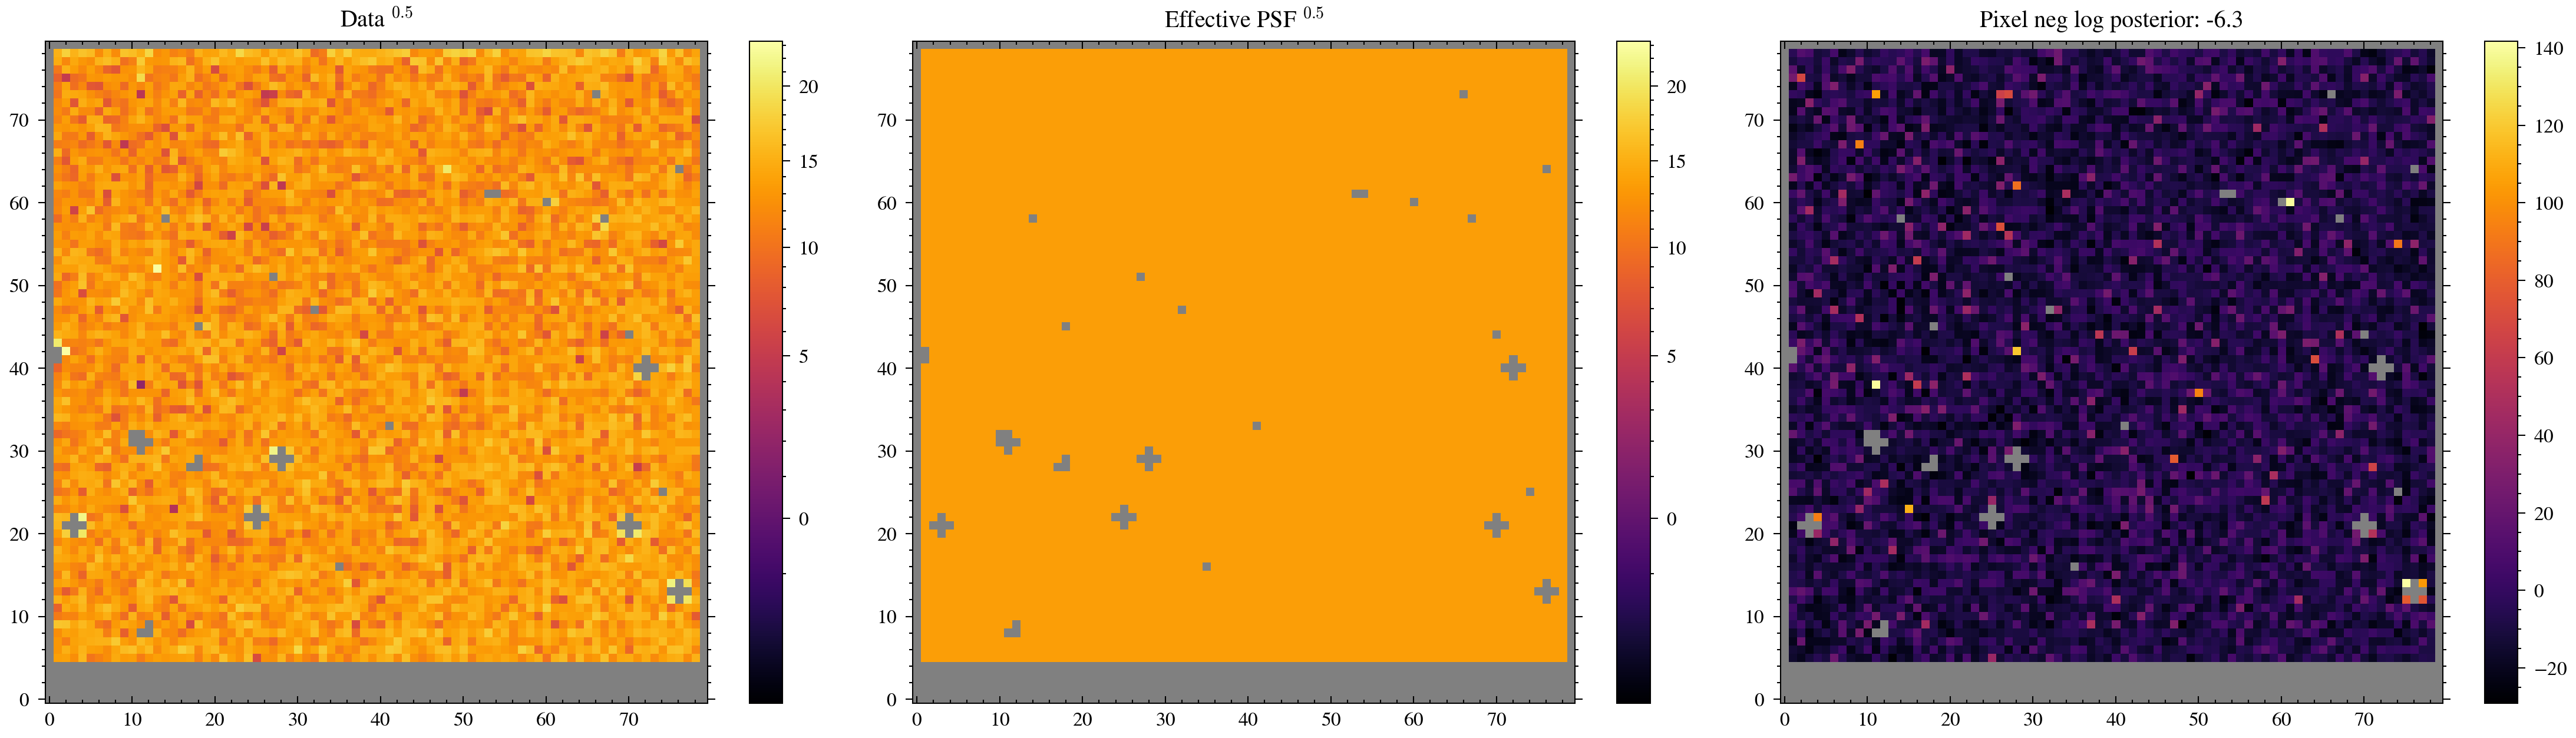

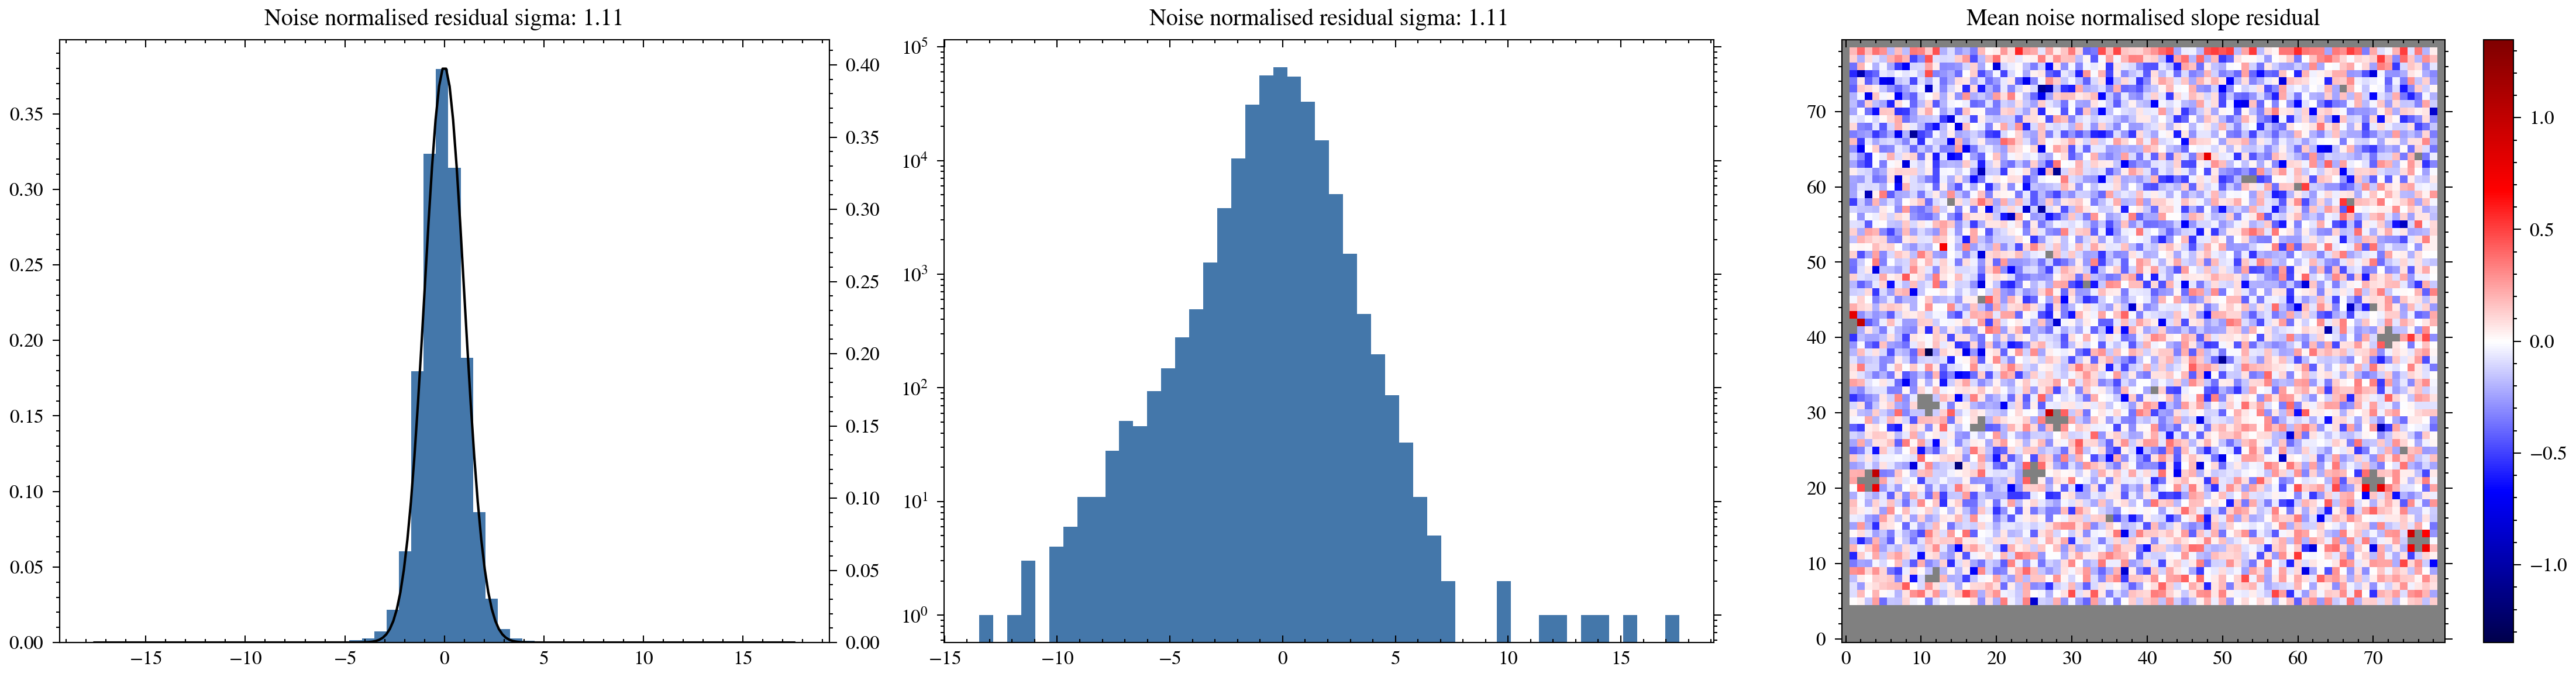

In [36]:
dark_map = result.model.get("dark_current")
dark_map = np.where(dark_exposures[1].badpix, np.nan, dark_map)

fig, ax = plt.subplots(1, 3, figsize=(9, 2))
im = ax[0].imshow(dark_map, inferno, norm=mpl.colors.PowerNorm(1., vmin=0))
ax[0].set_title(f"mean: {np.nanmean(dark_map):.4f}")
fig.colorbar(im)

im = ax[1].imshow(dark_map, seismic, norm=mpl.colors.CenteredNorm(np.nanmean(dark_map)))
ax[1].set_title(f"median: {np.nanmedian(dark_map):.4f}")
fig.colorbar(im)

ax[2].hist(dark_map.ravel(), bins=50)
ax[2].axvline(np.nanmean(dark_map), c="r", linewidth=0.5, label="mean")
ax[2].axvline(np.nanmedian(dark_map), c="k", linewidth=0.5, label="median")
# ax[2].set_title(f"median: {np.nanmode(dark_map):.4f}")
ax[2].legend()
plt.show()

# amigo.plotting.plot_losses(result.losses[0], start=int(epochs * 0.75))
amigo.plotting.plot(result.history)
if save_flag:
    amigo.plotting.plot(result.history, save_path=save_path)

for exp in exposures:
    exp.print_summary()
    summarise_fit(model, exp, histograms=True, residuals=True, up_the_ramp_norm=True)
    
    # if save_flag:
    #     amigo.plotting.summarise_fit(result.model, exp, save_path=this_save_path)